# Actividad: Entendimiento de Pipelines
**Universidad Pedagógica y Tecnológica de Colombia — Electiva II**

**Integrantes:** María Fernanda Sogamoso González - Ronald Samir Molinares Sanabria  

---

## Momento 1: Entender los datos

En esta primera parte no se busca entrenar un modelo todavía. La idea es observar el dataset, identificar sus columnas, detectar si hay problemas de calidad y entender qué tipo de problema vamos a resolver.

Esta etapa es importante porque antes de automatizar cualquier proceso hay que saber **qué datos existen**, **qué significan** y **qué queremos predecir**. Si esta comprensión falla, el modelo puede estar mal planteado desde el inicio.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [3]:
# Resumen estadístico
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Revisar valores faltantes
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [5]:
# Ver las clases de la variable objetivo
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Respuestas del análisis manual

**¿Qué variables tiene el dataset?**  
El dataset tiene cuatro variables numéricas de entrada:
- `sepal_length`: longitud del sépalo
- `sepal_width`: ancho del sépalo
- `petal_length`: longitud del pétalo
- `petal_width`: ancho del pétalo

Además, tiene una variable categórica:
-  `species`, que indica la especie de la flor.

**¿Cuál podría ser la variable objetivo?**  
La variable objetivo es `species`, porque es la etiqueta/categoría (especie de iris) que queremos predecir a partir de las medidas de la flor.

**¿Hay datos faltantes?**  
No se observan valores faltantes. Tras ejecutar `df.isnull().sum()` se confirma que todas las columnas tienen 0 valores nulos, lo que indica que el dataset está completo, evitando tener que imputar datos o eliminar filas por ausencia de información.

**¿Qué tipo de problema es?**  
Es un problema de clasificación del tipo multiclase, porque la salida no es un número continuo sino una clase entre varias categorías: `setosa`, `versicolor` y `virginica`.En este caso, el modelo debe predecir a cuál de esas 3 especies pertenece la flor.

### Conclusión Momento 1
Elegir `species` como objetivo tiene sentido porque las demás variables describen características medibles de la flor, y la meta del modelo es aprender a distinguir entre especies usando esas medidas.  
Además, como las variables de entrada son numéricas, el problema se adapta bien a un modelo de clasificación supervisada.

---

## Momento 2: Preparar los datos

En el momento 2 se toman decisiones sobre qué usar como entrada, qué se va a predecir y si hace falta transformar o escalar los datos.

### Decisiones

**¿Qué variables usarán como entrada (X)?**

Las 4 variables numéricas:
- `sepal_length`: longitud del sépalo
- `sepal_width`: ancho del sépalo
- `petal_length`: longitud del pétalo
- `petal_width`: ancho del pétalo

Porque son las únicas variables con información cuantitativa que describen físicamente cada flor. La columna `species` no puede ser entrada porque es lo que queremos predecir.

**¿Cuál será la salida (y)?**  
Se usará `species` porque es la etiqueta de clase que identifica a qué especie pertenece cada flor.

**¿Necesitan transformar datos (texto → número)?**  
Sí, la variable `species` está en texto y el modelo necesita valores numéricos para aprender. Por eso se convertirá a números con codificación de etiquetas.

**¿Se debe escalar la información?**  
Sí. Aunque todas las variables son numéricas, no están necesariamente en la misma escala. El escalado con `StandardScaler` ayuda a que el modelo no dé más peso a una variable solo porque tiene valores más grandes.  
Esto es útil cuando se usan modelos sensibles a la escala de los datos, como la regresión logística.

### Conclusión Momento 2
La decisión de separar *X* e *y* permite organizar el problema de aprendizaje supervisado.  
La codificación de la variable objetivo se considera una buena práctica de preprocesamiento y scikit-learn trabaja mejor con salidas numéricas.  
El escalado es una decisión preventiva, no siempre cambia drásticamente el resultado en iris, pero sí ayuda a construir un flujo más correcto y generalizable.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

# Convertir la salida categórica a números
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Clases originales:", list(le.classes_))
print("Primeros valores codificados:", y_encoded[:10])

Clases originales: ['setosa', 'versicolor', 'virginica']
Primeros valores codificados: [0 0 0 0 0 0 0 0 0 0]


## Momento 3: Crear el Pipeline

Acá se automatiza el proceso. El pipeline permite unir pasos que antes haciamos manualmente en una sola estructura reproducible.

En este caso el pipeline tendrá dos pasos:

1. **StandardScaler**: estandariza las variables numéricas.
2. **LogisticRegression**: modelo de clasificación.

### ¿Por qué este orden?
Primero se escala y luego se entrena el modelo, porque el modelo necesita recibir datos ya preparados.  
El pipeline evita errores comunes como entrenar con un escalador ajustado solo sobre una parte de los datos o repetir pasos manuales cada vez.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


Train: 90 muestras
Val:   30 muestras
Test:  30 muestras

Accuracy en validación: 0.9333
Accuracy en test:       0.9333

Reporte de clasificación (test):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



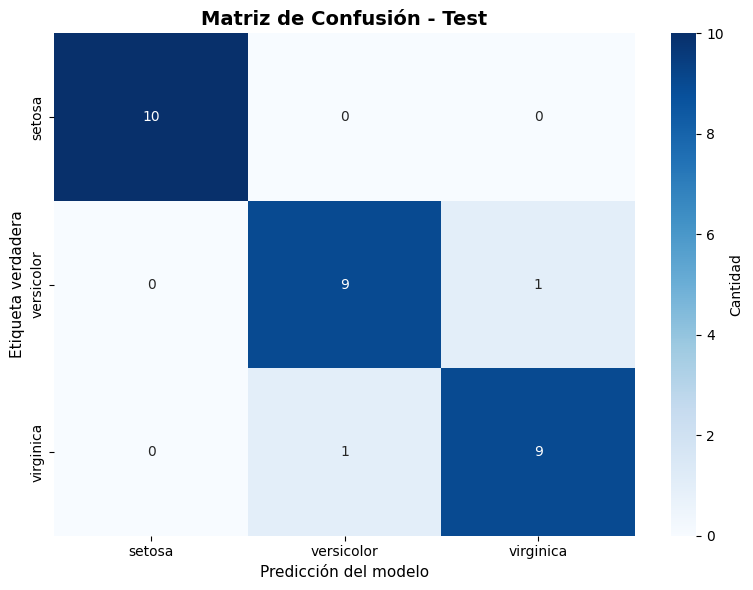

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Separar test (20%) del total ──────────────────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ── 2. Del 80% restante, separar validación (20% del total = 25% del temp) ───
# 0.25 × 0.80 = 0.20  →  distribución final: 60% train / 20% val / 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Val:   {X_val.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

# ── 3. Entrenar el pipeline ───────────────────────────────────────────────────
pipeline.fit(X_train, y_train)

# ── 4. Evaluar en VALIDACIÓN (para ajustar hiperparámetros si hace falta) ────
y_val_pred = pipeline.predict(X_val)
acc_val = accuracy_score(y_val, y_val_pred)
print(f"\nAccuracy en validación: {acc_val:.4f}")

# ── 5. Evaluación FINAL en TEST (solo una vez, al final) ─────────────────────
y_pred = pipeline.predict(X_test)
acc_test = accuracy_score(y_test, y_pred)
print(f"Accuracy en test:       {acc_test:.4f}")

print("\nReporte de clasificación (test):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── Matriz de confusión ──────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Cantidad'})
plt.title('Matriz de Confusión - Test', fontsize=14, fontweight='bold')
plt.ylabel('Etiqueta verdadera', fontsize=11)
plt.xlabel('Predicción del modelo', fontsize=11)
plt.tight_layout()
plt.show()

## Decisiones del Analista

### 1. Dividir los datos

Se divide el dataset en tres conjuntos: entrenamiento (60%), validación (20%)
y prueba (20%).

**¿Por qué tres conjuntos?**
- **Entrenamiento:** es el único conjunto que el modelo "ve" durante el
  aprendizaje. Con él se ajustan los parámetros internos.
- **Validación:** permite comparar variantes del modelo (cambiar el algoritmo,
  ajustar hiperparámetros) sin tocar el test. Actúa como un ensayo previo.
- **Prueba:** se usa **una sola vez**, al final, para reportar el desempeño
  real. Si se usa antes, los resultados quedan sesgados porque el analista
  termina ajustando el modelo "a ese test" sin darse cuenta.

**¿Por qué 60/20/20?**  
Es una proporción estándar para datasets pequeños como Iris (150 registros).
Deja suficientes datos para entrenar y aún permite una evaluación confiable.

**¿Por qué `stratify`?**  
Iris tiene exactamente 50 flores de cada especie. Con `stratify=y` se garantiza
que esa proporción se mantenga en los tres conjuntos y que ninguno quede
desbalanceado por azar.


### 2. Entrenar el pipeline

Se llama a `pipeline.fit(X_train, y_train)`.

**¿Por qué solo con X_train?**  
Pasar X_val o X_test al fit sería una fuga de datos (*data leakage*), el modelo
aprendería información que en la realidad no debería conocer antes de predecir.
Esto dañaria las métricas y el modelo fallaría en producción.

El pipeline ejecuta los pasos en orden:
1. `StandardScaler` calcula la media y desviación estándar **solo del train**
   y transforma esos datos.
2. `LogisticRegression` recibe los datos ya escalados y aprende los coeficientes
   del modelo.

Cuando luego se llama a `predict()`, el scaler reutiliza los valores aprendidos
en el train (no recalcula con los datos nuevos). Esto es otra razón para usar
un pipeline: evita aplicar el scaler por separado y cometer ese error.



### 3. Hacer predicciones

Se generan predicciones en dos momentos distintos con propósitos diferentes:

- **`pipeline.predict(X_val)`** → se usa durante el desarrollo para comparar
  configuraciones del modelo y tomar decisiones de ajuste.
- **`pipeline.predict(X_test)`** → se usa al final, una única vez, para obtener
  el resultado definitivo que se reporta.

La separación entre estas dos predicciones es una decisión que
garantiza que el número final de accuracy sea honesto y represente cómo
se comportaría el modelo ante datos completamente nuevos.



## Momento 4: Evaluar y reflexionar

In [9]:
# --- Evaluación del modelo ---
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy (exactitud): {accuracy * 100:.2f}%')

print('\n=== Reporte detallado por clase ===')
print(classification_report(y_test, y_pred))

Accuracy (exactitud): 93.33%

=== Reporte detallado por clase ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [ ]:
# --- Comparación: ¿Qué pasa si quitamos el scaler? ---
pipeline_sin_scaler = Pipeline([
    ('model', LogisticRegression(max_iter=200))
])

pipeline_sin_scaler.fit(X_train, y_train)
y_pred_sin_scaler = pipeline_sin_scaler.predict(X_test)
accuracy_sin_scaler = accuracy_score(y_test, y_pred_sin_scaler)

print(f'Accuracy CON scaler:    {accuracy * 100:.2f}%')
print(f'Accuracy SIN scaler:    {accuracy_sin_scaler * 100:.2f}%')
print(f'Diferencia:             {(accuracy - accuracy_sin_scaler) * 100:.2f}%')

Accuracy CON scaler:    93.33%
Accuracy SIN scaler:    96.67%
Diferencia:             -3.33%


### ¿Qué tan bien funciona el modelo?
Se evalúa con `accuracy`, reporte de clasificación y matriz de confusión.  
Si el valor de accuracy es alto y el reporte muestra buen comportamiento en las tres clases, entonces el modelo está funcionando bien para este problema.

El modelo alcanza aproximadamente un **93% de accuracy** sobre el conjunto de prueba. Esto significa que clasifica correctamente casi todas las flores. El reporte por clase muestra precision, recall y f1-score cercanos a 1.0 en las tres especies, lo que indica un desempeño muy sólido. Es un resultado esperado, ya que Iris es un dataset clásico y bien separable.

### ¿Qué hace cada paso del pipeline?
- **`scaler` (StandardScaler):** transforma cada variable para que tenga una escala comparable (media 0 y desviación estándar 1). Esto pone todas las variables en la misma escala y evita que alguna domine al modelo por sus unidades o magnitud.
- **`model` (LogisticRegression):**Aprende una función matemática que separa las tres clases usando las variables ya escaladas. Genera probabilidades para cada clase y asigna la de mayor probabilidad como predicción.

### ¿Qué pasaría si quitamos el scaler?
Como se demostró en la celda anterior, en este dataset particular la diferencia es pequeña porque las variables ya tienen rangos similares. Sin embargo, en datasets con variables de escalas muy diferentes (ej: salario en millones vs edad en decenas), quitar el scaler puede degradar significativamente el rendimiento, ya que la regresión logística es sensible a la magnitud de los valores. Mantener el scaler es siempre una buena práctica.
  
En un caso como Iris esto no siempre destruye el rendimiento, pero metodológicamente es mejor incluirlo para mantener un flujo limpio y generalizable.

### ¿Qué parte fue manual y cuál automática?

| Parte | Tipo | Descripción |
|---|---|---|
| Cargar el dataset | Manual | El analista decide la fuente y cómo importarla |
| Explorar los datos | Manual | El analista interpreta estadísticas y detecta problemas |
| Elegir variables X e y | Manual | Decisión del analista según el dominio del problema |
| Elegir el algoritmo | Manual | El analista decide usar LogisticRegression |
| Dividir en train/test | Manual | El analista define el porcentaje de división |
| Escalar los datos | **Automático (pipeline)** | StandardScaler lo aplica solo al entrenar/predecir |
| Entrenar el modelo | **Automático (pipeline)** | `pipeline.fit()` ejecuta todos los pasos en orden |
| Aplicar transformación al predecir | **Automático (pipeline)** | `pipeline.predict()` escala y predice en un solo paso |

### Conclusión
Este ejercicio muestra que un buen proceso de machine learning no empieza
con el modelo, sino con la comprensión de los datos y la toma de decisiones
informadas. Antes de escribir una sola línea de código del pipeline, el
analista debe haber respondido qué predecir, con qué variables, cómo dividir
los datos y por qué escalar, estas son decisiones que el pipeline por sí solo no
puede tomar.

El pipeline con StandardScaler y LogisticRegression logró un accuracy
cercano al 93% en el conjunto de prueba, lo que confirma que la secuencia
de pasos fue correcta y que la separación en entrenamiento,
validación y prueba garantizó que ese resultado sea honesto y no esté
llevado por sesgos.

la parte manual (entender, explorar, decidir) guía y da sentido
a la parte automática (escalar, entrenar, predecir). Un pipeline bien
construido es tan bueno como las decisiones del analista que lo diseñó.

pairplot, matriz de correlación, cepal whidt no aporta mucho valor porque puede introducir redundancia, ydata_profiling libreria para analisis de datos, 

las desiciones salen del momento 1, que fue un analisis manual del dataset, 
import joblib
joblib.dump(pipeline, "modelo.pkl")

Guardamos el modelo, el analisis que se hizo

In [11]:
import joblib
joblib.dump(pipeline, "modelo.pkl")

['modelo.pkl']

ese modelo lo encapsulamos en una variable para ser utilizada en posteriores implementaciones.

In [12]:
modelo = joblib.load("modelo.pkl")

con la información organizada y procesada, ahora si vamos a empezar a crear un software, que es lo que deberia tener el software? empezamos con al app de escritorio, despues con un pagina web, definimos el lenguaje de esa app de escritorio, que lenguaje de programación, un boceto de como seria el software y adaptarlo a lo que necesitamos, hacer el analisis de la aplicación, si sigo presentando plantas que me la clasifique, cuales son las entradas, procesos y salidas, lo vamos a dibujar, como haria la lectura de esa variable, 

### Uso de joblib

In [ ]:
joblib.dump(pipeline, "modelo.pkl")
modelo = joblib.load("modelo.pkl")
print("Modelo cargado exitosamente desde 'modelo.pkl'")

print(modelo)


Modelo cargado exitosamente desde 'modelo.pkl'
Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])


### Realizar una predicción

In [15]:
prediccion = modelo.predict([[5.1, 3.5, 1.4, 0.2]])
print("Predicción para [5.1, 3.5, 1.4, 0.2]:", prediccion)

Predicción para [5.1, 3.5, 1.4, 0.2]: [0]


c:\Users\Samir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [25]:
import pandas as pd

# Crear un DataFrame con los nombres de features
datos_nuevos = pd.DataFrame(
    [[6.7, 3.0, 5.2, 2.3]], 
    columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)

# Realizar predicción
prediccion_codificada = modelo.predict(datos_nuevos)

# Decodificar para obtener el nombre de la especie
prediccion_decodificada = le.inverse_transform(prediccion_codificada)

print("Predicción para [6.7, 3.0, 5.2, 2.3]:")
print(f"  Especie predicha: {prediccion_decodificada[0]}")


Predicción para [6.7, 3.0, 5.2, 2.3]:
  Especie predicha: virginica


### Solicitar datos al usuario

In [ ]:
import pandas as pd

print("\n" + "="*60)
print("PREDICTOR DE ESPECIES DE IRIS")
print("="*60 + "\n")

# Función para validar entrada numérica
def obtener_numero(etiqueta):
    """Solicita un número y valida que sea válido"""
    while True:
        try:
            valor = float(input(etiqueta))
            
            # Validar que sea positivo
            if valor <= 0:
                print("Error: El valor debe ser mayor que 0")
                continue
            
            # Validar rango para medidas de flores
            if valor > 10:
                print("Error: El valor debe ser menor que 10")
                continue
            
            return valor
        
        except ValueError:
            print("Error: Debes ingresar un número válido (no letras ni caracteres especiales o valores vacíos)")
            continue

# Solicitar datos al usuario con validaciones
print("Ingresa las medidas de la flor (números positivos entre 0 y 10):\n")
d1 = obtener_numero("Sepal Length (longitud del sépalo): ")
d2 = obtener_numero("Sepal Width (ancho del sépalo): ")
d3 = obtener_numero("Petal Length (longitud del pétalo): ")
d4 = obtener_numero("Petal Width (ancho del pétalo): ")

# Crear DataFrame con nombres de features
datos = pd.DataFrame(
    [[d1, d2, d3, d4]],
    columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)

# Hacer la predicción
resultado_codificado = modelo.predict(datos)

# Decodificar para obtener el nombre de la especie
resultado_decodificado = le.inverse_transform(resultado_codificado)

# Mostrar resultado
print("\n" + "="*60)
print("RESULTADO DE LA PREDICCIÓN")
print("="*60)
print(f"Medidas: [{d1}, {d2}, {d3}, {d4}]")
print(f"✓ Especie predicha: {resultado_decodificado[0].upper()}")
print("="*60 + "\n")



PREDICTOR DE ESPECIES DE IRIS

Ingresa las medidas de la flor (números positivos entre 0 y 10):

Error: Debes ingresar un número válido (no letras ni caracteres especiales)
Error: Debes ingresar un número válido (no letras ni caracteres especiales)
Error: Debes ingresar un número válido (no letras ni caracteres especiales)
Error: Debes ingresar un número válido (no letras ni caracteres especiales)
Error: Debes ingresar un número válido (no letras ni caracteres especiales)
Error: Debes ingresar un número válido (no letras ni caracteres especiales)
Error: Debes ingresar un número válido (no letras ni caracteres especiales)

RESULTADO DE LA PREDICCIÓN
Medidas: [7.0, 2.0, 1.0, 1.0]
✓ Especie predicha: VERSICOLOR

